# Course NIGK21007U - Integrated Water Resources Modelling
## Reading and Processing dfs0 files

dfs0 is a proprietary binary file format by DHI. It is used to store time series data, so it only has one independent variable, time. This notebook shows you how to read and process such files in python.

First, import all necessary python packages:

In [45]:
import mikeio
from mikeio import Dfs0
import matplotlib.pyplot as plt

mikeio is a python library made by DHI that enables interaction with dfs file format. matplotlib is a plotting and visualization package. 

Next, specify the name of the dfs0 file you want to read. **r'...'** makes sure that the filename is read as a raw string and backslashes are not interpreted as line breaks. Obviously, you need to adjust path and file name so that they point to an existing dfs0 file on your system.

In [46]:
my_file_name = r'c:\Users\vpk410\Documents\DK1\DK1_HIPmodels\Setup\DK1_HIP_500m.she - Result Files\DK1_HIP_500mDetailedTS_SZ.dfs0'

Next, open the file to get a Dfs0 object. After this step, metadata is available but data isn't loaded yet.

In [47]:
dfs0 = Dfs0(my_file_name)

Inspect file properties (e.g., number of time steps, items):

In [48]:
print(f"Number of time steps: {dfs.n_timesteps}")
print(f"Item names: {[item.name for item in dfs.items]}")

Number of time steps: 4
Item names: ['182.248_1', '182.317_1', '182.319_1', '182.319_2', '182.332_1', '182.333_1', '182.333_2', '182.333_3', '182.335_1', '182.402_1', '186.51_1', '186.54_1', '186.55_1', '187.1013_1', '187.1014_1', '187.1016_1', '187.1020_1', '187.1020_2', '187.1020_3', '187.1045_1', '187.1047_1', '187.1055_1', '187.1057_1', '187.1061_1', '187.1061_2', '187.1261_1', '187.14_1', '187.15_1', '187.16_1', '187.58_1', '187.67_1', '187.72_1', '187.73_1', '187.74_1', '187.76_1', '187.83_1', '187.952_1', '187.99_1', '188.138_1', '188.179_1', '188.388_1', '188.389_1', '190.113_1', '190.131_1', '190.150_1', '190.161_1', '190.163_1', '190.166_1', '190.167_1', '190.168_1', '190.171_1', '190.172_1', '190.204_1', '190.210_1', '190.217_1', '190.285_1', '190.73_1', '190.78_1', '191.102_1', '191.107_1', '191.111_1', '191.117_1', '191.118_1', '191.133_1', '191.152_1', '191.154_1', '191.159_1', '191.160_1', '191.162_1', '191.163_1', '191.164_1', '191.165_1', '191.171_1', '191.172_1', '191

Define an item you are interested in:

In [49]:
my_item = r'182.248_1'

Read the Dataset (ds):

In [50]:
ds = mikeio.read(my_file_name, items=[my_item])

Extract the time indices from the file:

In [51]:
time_array_datetime = ds.time.values
print(time_array_datetime)

['1989-01-02T12:00:00.000000000' '1989-01-03T13:47:59.999000000'
 '1989-01-04T23:55:13.793000000' '1989-01-05T20:54:30.856000000']


Get the unit of the item - take not of the use of repr here - unit itself is a DHI code.

In [52]:
unit = repr(ds[my_item].unit)
print(unit)

meter


Get the DataArray for the item of interest. The shape of the underlying data is (time).

In [53]:
data_array = ds[my_item]
print(data_array.shape)

(4,)


Make a time series plot:

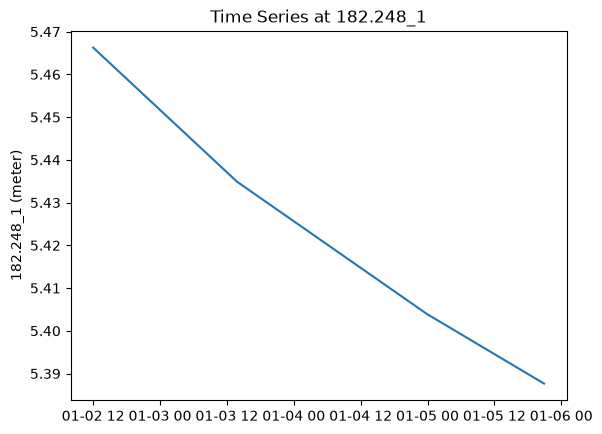

In [54]:
fig, ax = plt.subplots()
ax.plot(time_array_datetime, data_array)
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at {my_item}")
plt.show()